In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("C:/Data_Analyst_Journey/Luke Barousse/job_postings_flat.csv")

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
job = 'Data Analyst'
country = 'United States'

df_selected = df[(df['job_title_short']==job) & (df['job_country']==country)].copy().dropna(subset='salary_year_avg')
df_exploded = df_selected.explode('job_skills')

df_grouped = df_exploded.groupby('job_skills').agg(
    skill_count = ('salary_year_avg', 'count'),
    median_salary = ('salary_year_avg', 'median')).sort_values(by='skill_count', ascending=False)

df_grouped['skill_percent'] = 100 * df_grouped['skill_count'] / len(df_selected)

mininmum_percentage = 5

df_grouped = df_grouped[df_grouped['skill_percent'] > 5]
df_grouped

,skill_count,median_salary,skill_percent
job_skills,,,
sql,5941,95000.0,51.109773
excel,5308,83500.0,45.664143
python,3741,100000.0,32.183414
tableau,3350,95500.0,28.819683
power bi,2372,90000.0,20.406056
r,2173,95298.5,18.694081
sas,2020,90000.0,17.377839
powerpoint,971,82350.0,8.353407
word,951,79500.0,8.181349


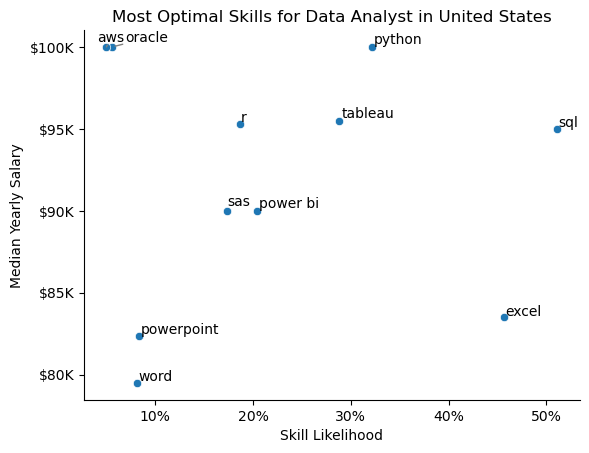

In [3]:
from adjustText import adjust_text

sns.scatterplot(
    data=df_grouped,
    x='skill_percent',
    y='median_salary'
)
sns.despine()

texts = []

for i, txt in enumerate(df_grouped.index):
    texts.append(plt.text(df_grouped['skill_percent'].iloc[i], df_grouped['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray'))

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y/1000:.0f}K'))

plt.title(f'Most Optimal Skills for {job} in {country}')
plt.xlabel('Skill Likelihood')
plt.ylabel('Median Yearly Salary')

plt.show()

In [4]:
skills_type = df_selected['job_type_skills'].dropna().drop_duplicates()

technologies_dict = {}

for row in skills_type:
    row_dict = ast.literal_eval(row)

    for key, value in row_dict.items():
        if key in technologies_dict:
            technologies_dict[key] += value
        else:
            technologies_dict[key] = value

for key, value in technologies_dict.items():
    technologies_dict[key] = list(set(value))

skills_technologie_df = pd.DataFrame(technologies_dict.items(), columns=['technology', 'skills'])
skills_technologie_df = skills_technologie_df.explode('skills')

df_plot = df_grouped.merge(skills_technologie_df, left_on='job_skills', right_on='skills')
df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,5941,95000.0,51.109773,programming,sql
1,5308,83500.0,45.664143,analyst_tools,excel
2,3741,100000.0,32.183414,programming,python
3,3350,95500.0,28.819683,analyst_tools,tableau
4,2372,90000.0,20.406056,analyst_tools,power bi
5,2173,95298.5,18.694081,programming,r
6,2020,90000.0,17.377839,analyst_tools,sas
7,2020,90000.0,17.377839,programming,sas
8,971,82350.0,8.353407,analyst_tools,powerpoint
9,951,79500.0,8.181349,analyst_tools,word


6 [-0.71657221  0.83909385]
7 [-0.6386324   0.79921601]


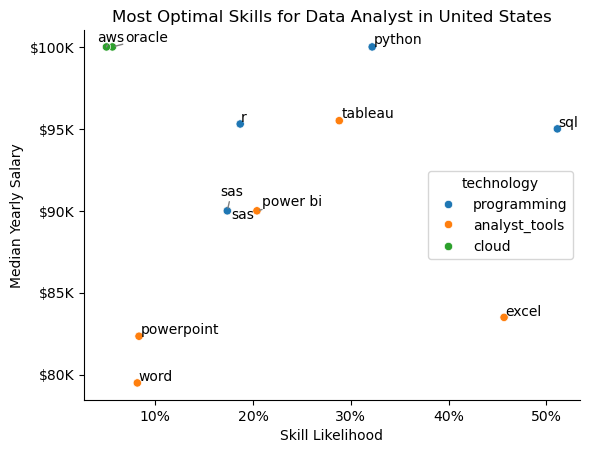

In [5]:
from adjustText import adjust_text

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)
sns.despine()

texts = []

for i, txt in enumerate(df_plot['skills']):
    texts.append(plt.text(df_plot['skill_percent'].iloc[i], df_plot['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray'))

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y/1000:.0f}K'))

plt.title(f'Most Optimal Skills for {job} in {country}')
plt.xlabel('Skill Likelihood')
plt.ylabel('Median Yearly Salary')

plt.show()